<a href="https://colab.research.google.com/github/AJULUMEL/PCVK25_3F_07/blob/main/week10_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Dandi Azrul Syahputra

Kelas : TI - 3F

No.absen : 07

# Praktikum 1

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

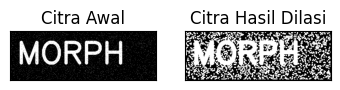

In [7]:
#Dilasi tanpa library
def dilasi_citra(F,w):
    #size image
    p,q= F.shape
    imgD= np.zeros((p,q), dtype=np.uint8)
    #Generate structure element dilasi (SED)
    SED= np.ones((w,w), dtype=np.uint8)
    constant1= (w-1)//2
    #Proses Dilasi
    for i in range(constant1, p-constant1):
        for j in range(constant1,q-constant1):
            temp= F[i-constant1:i+constant1+1, j-constant1:j+constant1+1]
            product= temp * SED
            imgD[i,j]= np.max(product)
    return imgD

img_d= cv2.imread('/content/drive/MyDrive/PCVK3F/Pertemuan 10/noisy_text.png',0)

# Add a check to see if the image was loaded successfully
if img_d is None:
    print("Error: Image not loaded. Please check the file path.")
else:
    ret, thresh = cv2.threshold(img_d, 125, 200, cv2.THRESH_BINARY)
    w=5
    imgD = dilasi_citra(thresh,w)
    plt.subplot(131),plt.imshow(img_d,cmap = 'gray')
    plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
    plt.subplot(132),plt.imshow(imgD,cmap = 'gray')
    plt.title('Citra Hasil Dilasi'), plt.xticks([]), plt.yticks([])
    plt.show()

[[1 1 1]
 [1 1 1]
 [1 1 1]]


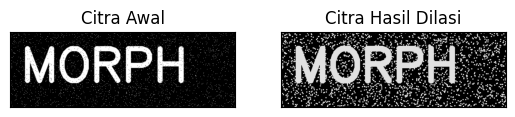

In [8]:
img = cv2.imread('/content/drive/MyDrive/PCVK3F/Pertemuan 10/noisy_text.png')
#img = cv2.imread('morp.jpg',0)
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
kernel = np.ones((3,3),np.uint16)
dilasi = cv2.dilate(thresh,kernel,iterations = 1)
print(kernel)
plt.subplot(121),plt.imshow(img),plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(dilasi),plt.title('Citra Hasil Dilasi')
plt.xticks([]), plt.yticks([])
plt.show()

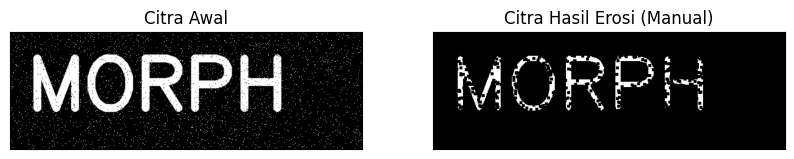

In [9]:
def erosi_citra(F, k):
    # Ukuran citra
    m, n = F.shape

    # Membuat Structuring Element (SE) berbentuk square k x k
    SE = np.ones((k, k), dtype=np.uint8)
    constant = (k - 1) // 2

    # Membuat array hasil (kosong)
    imgE = np.zeros((m, n), dtype=np.uint8)

    # Proses Erosi
    for i in range(constant, m - constant):
        for j in range(constant, n - constant):
            # Ambil area lokal sesuai ukuran SE
            temp = F[i - constant:i + constant + 1, j - constant:j + constant + 1]

            # Operasi erosi (ambil nilai minimum hasil perkalian dengan SE)
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE

# Membaca citra dalam mode grayscale
img_e = cv2.imread('/content/drive/MyDrive/PCVK3F/Pertemuan 10/noisy_text.png', 0)

# Thresholding biner untuk mempermudah operasi morfologi
ret1, thresh1 = cv2.threshold(img_e, 175, 225, cv2.THRESH_BINARY)

# Ukuran kernel (Structuring Element)
k = 5

# Proses erosi menggunakan fungsi manual
imgE = erosi_citra(thresh1, k)

# Menampilkan hasil
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi (Manual)'), plt.xticks([]), plt.yticks([])

plt.show()

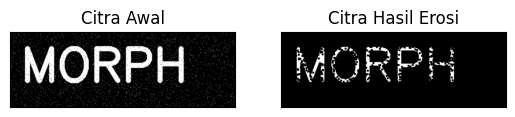

In [10]:
#EROSI LIBRARY
img = cv2.imread('/content/drive/MyDrive/PCVK3F/Pertemuan 10/noisy_text.png')
kernel = np.ones((5,5),np.uint8)
erosion = cv2.erode(img,kernel,iterations = 1)
plt.subplot(121),plt.imshow(img),plt.title('Citra Awal')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(erosion),plt.title('Citra Hasil Erosi')
plt.xticks([]), plt.yticks([])
plt.show()

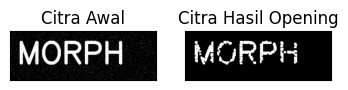

In [11]:
img_o= cv2.imread('/content/drive/MyDrive/PCVK3F/Pertemuan 10/noisy_text.png',0) #
reto, thresho = cv2.threshold(img_o, 127, 225,
cv2.THRESH_BINARY)
k=7
imgO = dilasi_citra(erosi_citra(thresho,k),k)
plt.subplot(131),plt.imshow(img_o,cmap = 'gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(imgO,cmap = 'gray')
plt.title('Citra Hasil Opening'), plt.xticks([]), plt.yticks([])
plt.show()

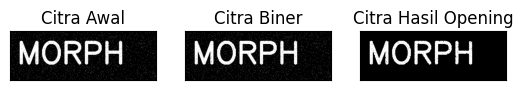

In [12]:
#Dengan Menggunakan Library
img = cv2.imread('/content/drive/MyDrive/PCVK3F/Pertemuan 10/noisy_text.png',0)
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
kernel = np.ones((3,3),np.uint8)
openn = cv2.morphologyEx(thresh,cv2.MORPH_OPEN, kernel)
plt.subplot(131),plt.imshow(img,cmap = 'gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(thresh,cmap = 'gray')
plt.title('Citra Biner'), plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(openn,cmap = 'gray')
plt.title('Citra Hasil Opening'), plt.xticks([]),
plt.yticks([])
plt.show()

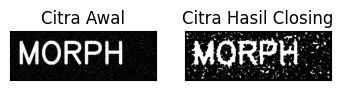

In [13]:
img_c= cv2.imread('/content/drive/MyDrive/PCVK3F/Pertemuan 10/noisy_text.png',0) #
retc, threshc = cv2.threshold(img_c, 127, 225,
cv2.THRESH_BINARY)
k=7
imgC = erosi_citra(dilasi_citra(threshc,k),k)
plt.subplot(131),plt.imshow(img_c,cmap = 'gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(imgC,cmap = 'gray')
plt.title('Citra Hasil Closing'), plt.xticks([]),
plt.yticks([])
plt.show()

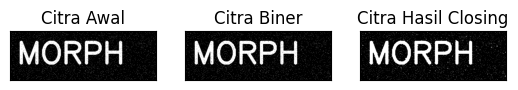

In [14]:
img = cv2.imread('/content/drive/MyDrive/PCVK3F/Pertemuan 10/noisy_text.png',0)
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
kernel = np.ones((3,3),np.uint8)
closs = cv2.morphologyEx(thresh,cv2.MORPH_CLOSE, kernel)
plt.subplot(131),plt.imshow(img,cmap = 'gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(thresh,cmap = 'gray')
plt.title('Citra Biner'), plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(closs,cmap = 'gray')
plt.title('Citra Hasil Closing'), plt.xticks([]), plt.yticks([])
plt.show()

SED = Cross 3


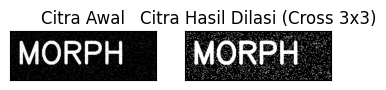

SED = Cross 5


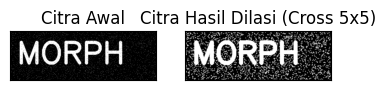

In [15]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# ==================================================
# DILASI CROSS 3x3
# ==================================================
def dilasi_citra(F, w):
    # Ukuran citra
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    # Structuring Element berbentuk Cross 3x3
    SED = np.array([[0, 1, 0],
                    [1, 1, 1],
                    [0, 1, 0]], dtype=np.uint8)

    constant1 = (w - 1) // 2

    # Proses Dilasi
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)
    return imgD


print('SED = Cross 3')
img_d = cv2.imread('/content/drive/MyDrive/PCVK3F/Pertemuan 10/noisy_text.png', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 3

imgD = dilasi_citra(thresh, w)

plt.subplot(131), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(132), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi (Cross 3x3)'), plt.xticks([]), plt.yticks([])

plt.show()

def dilasi_citra(F, w):
    # Ukuran citra
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    # Structuring Element berbentuk Cross 5x5
    SED = np.array([[0, 0, 1, 0, 0],
                    [0, 0, 1, 0, 0],
                    [1, 1, 1, 1, 1],
                    [0, 0, 1, 0, 0],
                    [0, 0, 1, 0, 0]], dtype=np.uint8)

    constant1 = (w - 1) // 2

    # Proses Dilasi
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)
    return imgD


print('SED = Cross 5')
img_d = cv2.imread('/content/drive/MyDrive/PCVK3F/Pertemuan 10/noisy_text.png', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 5

imgD = dilasi_citra(thresh, w)

plt.subplot(131), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(132), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi (Cross 5x5)'), plt.xticks([]), plt.yticks([])

plt.show()


SED = Circle 3x3


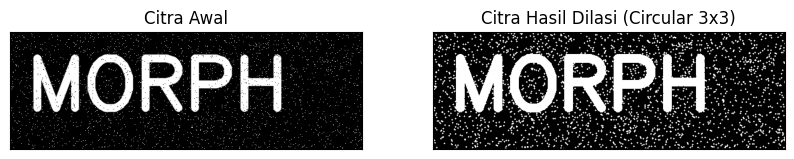

SED = Circle 5x5


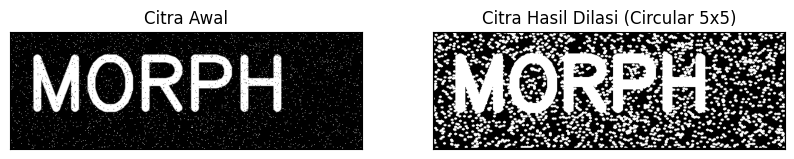

In [16]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def dilasi_citra(F, w):
    # Ukuran citra
    p, q = F.shape
    imgD = np.zeros((p, q), dtype=np.uint8)

    # Membuat Structuring Element berbentuk lingkaran (circular)
    SED = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (w, w))

    constant1 = (w - 1) // 2

    # Proses Dilasi
    for i in range(constant1, p - constant1):
        for j in range(constant1, q - constant1):
            temp = F[i - constant1:i + constant1 + 1, j - constant1:j + constant1 + 1]
            product = temp * SED
            imgD[i, j] = np.max(product)

    return imgD

print('SED = Circle 3x3')
img_d = cv2.imread('/content/drive/MyDrive/PCVK3F/Pertemuan 10/noisy_text.png', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 3
imgD = dilasi_citra(thresh, w)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi (Circular 3x3)'), plt.xticks([]), plt.yticks([])
plt.show()

print('SED = Circle 5x5')
img_d = cv2.imread('/content/drive/MyDrive/PCVK3F/Pertemuan 10/noisy_text.png', 0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w = 5
imgD = dilasi_citra(thresh, w)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_d, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2), plt.imshow(imgD, cmap='gray')
plt.title('Citra Hasil Dilasi (Circular 5x5)'), plt.xticks([]), plt.yticks([])
plt.show()


SE = Rectangle 3x5


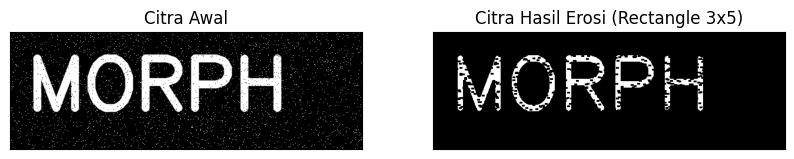

SE = Rectangle 5x7


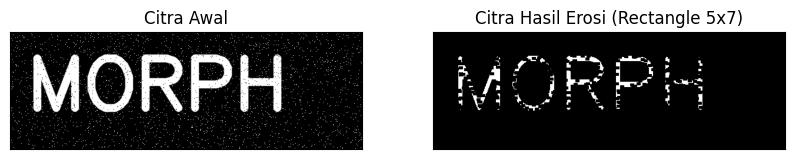

In [17]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def erosi_citra(F, p, l):
    # Ukuran citra
    m, n = F.shape

    # Membuat Structuring Element berbentuk persegi panjang
    SE = cv2.getStructuringElement(cv2.MORPH_RECT, (p, l))

    # Nilai batas untuk iterasi (margin)
    constant1 = (l - 1) // 2
    constant2 = (p - 1) // 2

    imgE = np.zeros((m, n), dtype=np.uint8)

    # Proses Erosi (mengambil nilai minimum pada area SE)
    for i in range(constant1, m - constant1):
        for j in range(constant2, n - constant2):
            temp = F[i - constant1:i + constant1 + 1, j - constant2:j + constant2 + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE

print('SE = Rectangle 3x5')
img_e = cv2.imread('/content/drive/MyDrive/PCVK3F/Pertemuan 10/noisy_text.png', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)

p = 5  # lebar (kolom)
l = 3  # tinggi (baris)
imgE = erosi_citra(thresh1, p, l)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi (Rectangle 3x5)'), plt.xticks([]), plt.yticks([])
plt.show()

print('SE = Rectangle 5x7')
img_e = cv2.imread('/content/drive/MyDrive/PCVK3F/Pertemuan 10/noisy_text.png', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)

p = 7  # lebar
l = 5  # tinggi
imgE = erosi_citra(thresh1, p, l)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi (Rectangle 5x7)'), plt.xticks([]), plt.yticks([])
plt.show()


SE = Line Vertikal 3


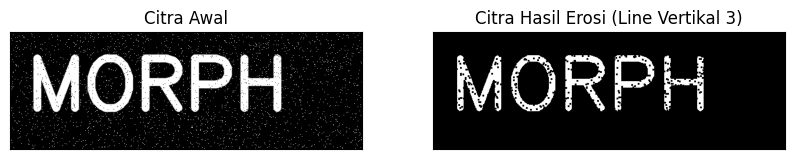

SE = Line Vertikal 5


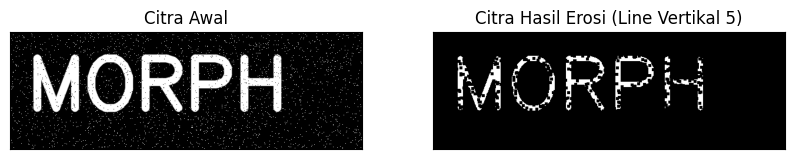

In [18]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def erosi_citra(F, k):
    # Ukuran citra
    m, n = F.shape

    # Membuat Structuring Element berbentuk garis vertikal
    SE = cv2.getStructuringElement(cv2.MORPH_RECT, (1, k))  # Line vertikal

    constant = (k - 1) // 2
    imgE = np.zeros((m, n), dtype=np.uint8)

    # Proses Erosi (mengambil nilai minimum pada area SE)
    for i in range(constant, m - constant):
        for j in range(constant, n - constant):
            temp = F[i - constant:i + constant + 1, j - constant:j + constant + 1]
            product = temp * SE
            imgE[i, j] = np.min(product)

    return imgE

print('SE = Line Vertikal 3')
img_e = cv2.imread('/content/drive/MyDrive/PCVK3F/Pertemuan 10/noisy_text.png', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)

k = 3
imgE = erosi_citra(thresh1, k)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi (Line Vertikal 3)'), plt.xticks([]), plt.yticks([])
plt.show()

print('SE = Line Vertikal 5')
img_e = cv2.imread('/content/drive/MyDrive/PCVK3F/Pertemuan 10/noisy_text.png', 0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)

k = 5
imgE = erosi_citra(thresh1, k)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_e, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2), plt.imshow(imgE, cmap='gray')
plt.title('Citra Hasil Erosi (Line Vertikal 5)'), plt.xticks([]), plt.yticks([])
plt.show()


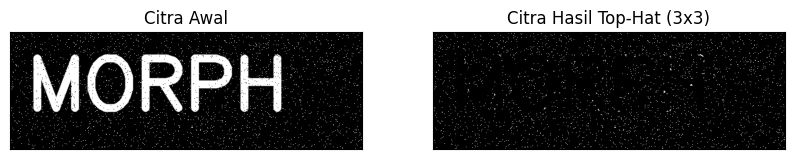

In [19]:
# Getting the kernel to be used in Top-Hat
filterSize = (3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)

# Reading the image named 'input.jpg'
img = cv2.imread('/content/drive/MyDrive/PCVK3F/Pertemuan 10/noisy_text.png')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Applying the Top-Hat operation
tophat_img = cv2.morphologyEx(img_gray, cv2.MORPH_TOPHAT, kernel)

#cv2.imshow("original", input_image)
#cv2.imshow("tophat", tophat_img)
#cv2.waitKey(5000)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1), plt.imshow(img_gray, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])
plt.subplot(1, 2, 2), plt.imshow(tophat_img, cmap='gray')
plt.title('Citra Hasil Top-Hat (3x3)'), plt.xticks([]), plt.yticks([])
plt.show()

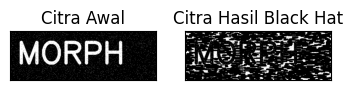

In [20]:
filterSize = (3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)

# Reading the image named 'input.jpg'
img = cv2.imread('/content/drive/MyDrive/PCVK3F/Pertemuan 10/noisy_text.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Applying the Black-Hat operation
# tophat_img = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)
Kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, Kernel)

# Pengolahan Citra dan Visi Komputer – Jurusan Teknologi Informasi
# cv2.imshow("original", input_image)
# cv2.imshow("tophat", tophat_img)
# cv2.waitKey(5000)

plt.subplot(131), plt.imshow(img, cmap='gray')
plt.title('Citra Awal'), plt.xticks([]), plt.yticks([])

plt.subplot(132), plt.imshow(blackhat, cmap='gray')
plt.title('Citra Hasil Black Hat'), plt.xticks([]), plt.yticks([])

plt.show()

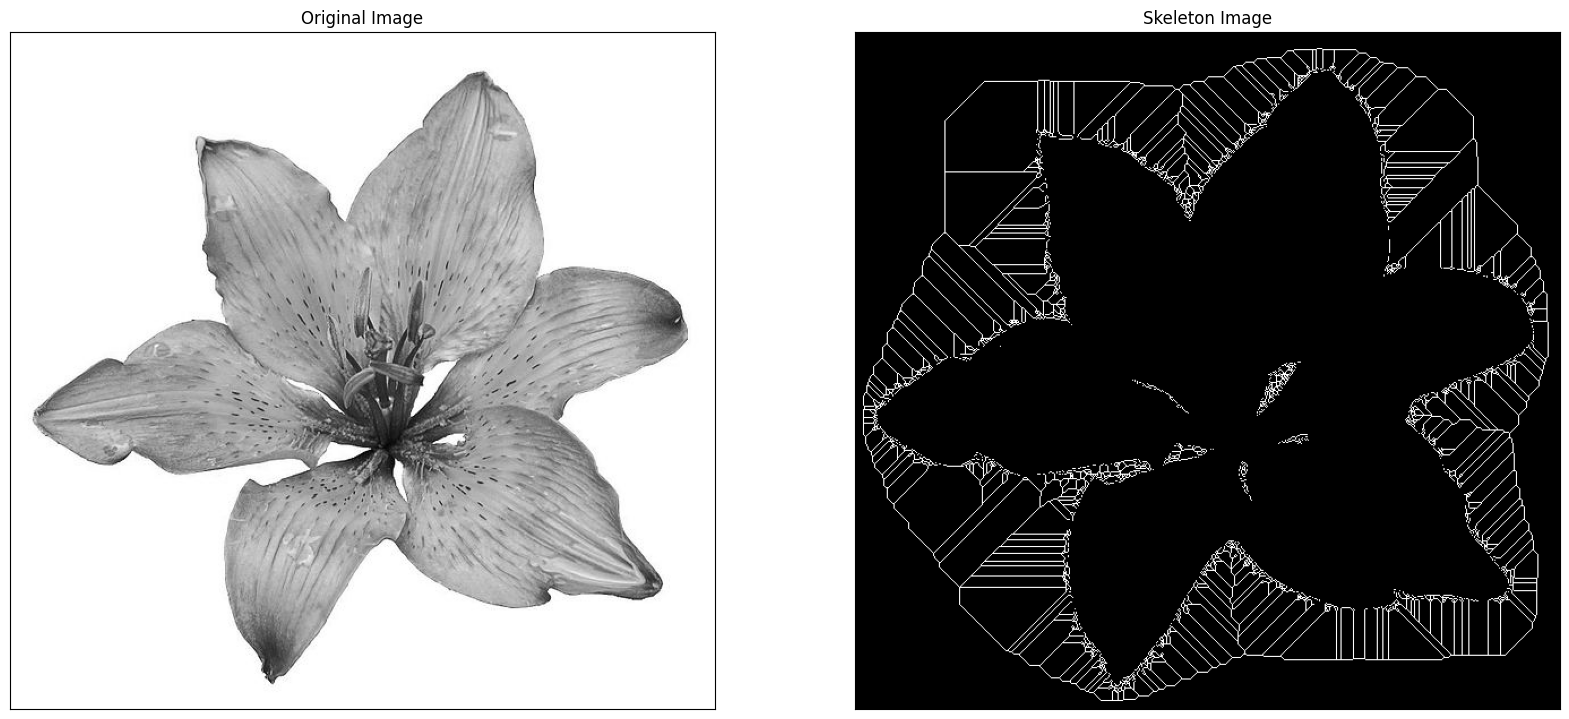

In [23]:
import cv2 as cv
from matplotlib import pyplot as plt
from skimage import filters
from skimage.morphology import skeletonize
# Read image
img = cv.imread('/content/lily.jpg', 0)

# Thresholding using Triangle method
binary = img > filters.threshold_triangle(img)

# Convert True/False to 1/0
binary_cp = binary.copy()
binary_cp[binary_cp == True] = 1
binary_cp[binary_cp == False] = 0

# Skeletonize image
skeleton = skeletonize(binary_cp)

# Display images
plt.figure(figsize=(20, 20))
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(skeleton, cmap='gray')
plt.title('Skeleton Image'), plt.xticks([]), plt.yticks([])
plt.savefig("binary_and_bin_skeleton.png")
plt.show()

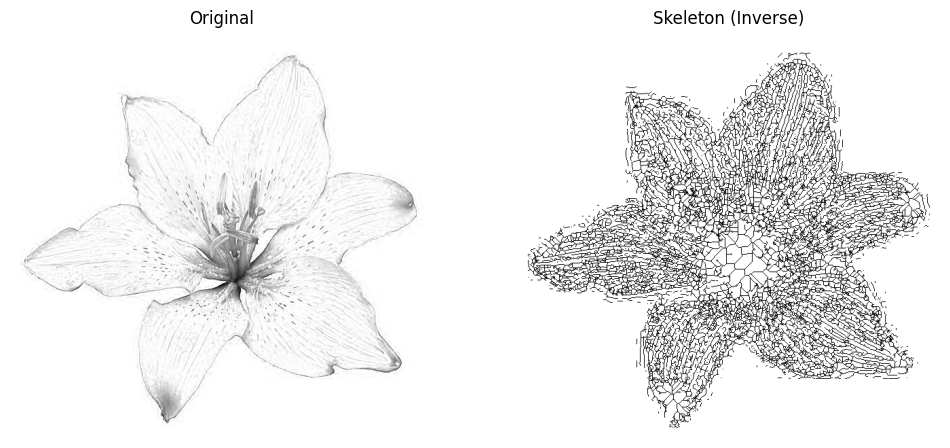

In [24]:
from skimage import io
from matplotlib import pyplot as plt
from skimage import filters
from skimage.morphology import skeletonize

# Read image
img = io.imread('/content/lily.jpg')[..., 0]

# Note: we want the black bits to be True, so use <
binary = img < filters.threshold_triangle(img)

# Skeletonize image
skeleton = skeletonize(binary)

# Display images
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original')
ax[0].set_axis_off()

# Note the reversed colormap, gray_r
ax[1].imshow(skeleton, cmap='gray_r')
ax[1].set_title('Skeleton (Inverse)')
ax[1].set_axis_off()


plt.show()

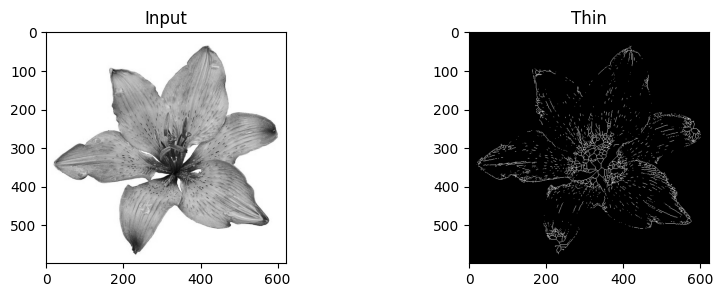

In [25]:
from skimage import img_as_float
from skimage import io, color, morphology
import matplotlib.pyplot as plt

# Membaca dan mengubah citra menjadi grayscale float
image = img_as_float(color.rgb2gray(io.imread('/content/lily.jpg')))

# Membuat citra biner
image_binary = image < 0.5

# Melakukan skeletonize dan thinning
out_skeletonize = morphology.skeletonize(image_binary)
out_thin = morphology.thin(image_binary)

# Menampilkan hasil
f, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3))
ax0.imshow(image, cmap='gray')
ax0.set_title('Input')
ax0.axis('on')

ax1.imshow(out_thin, cmap='gray')
ax1.set_title('Thin')
ax1.axis('on')

plt.savefig('/tmp/char_out.png')
plt.show()